|                |   |
:----------------|---|
| **Nombre**     | Valeria Guzmán Galván  |
| **Fecha**      | 23/03/2026  |
| **Expediente** | 756902  |

# Métodos de Búsqueda

Aplicar el método de optimización gaussiana para encontrar el valor óptimo de una función desconocida, utilizando un modelo de proceso gaussiano que permite estimar la función y su incertidumbre.

## Prueba 1
|                |   |
:----------------|---|
| *x*     |*y*  |
| 10      |2847  |
| 2|-4017   |
| 3|-1255   |
| 7|1773  |
| 12|563   |

In [213]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

In [214]:
x = np.array([10, 2, 3, 7, 12]).reshape(-1, 1)
y = np.array([2847, -4017, -1255, 1773, 563])

In [215]:
gp = GaussianProcessRegressor(n_restarts_optimizer=10)

In [216]:
gp.fit(x, y)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [217]:
x_sim = np.linspace(2, 15, 10001).reshape(-1,1)

In [218]:
ypred, sigma = gp.predict(x_sim, return_std=True)

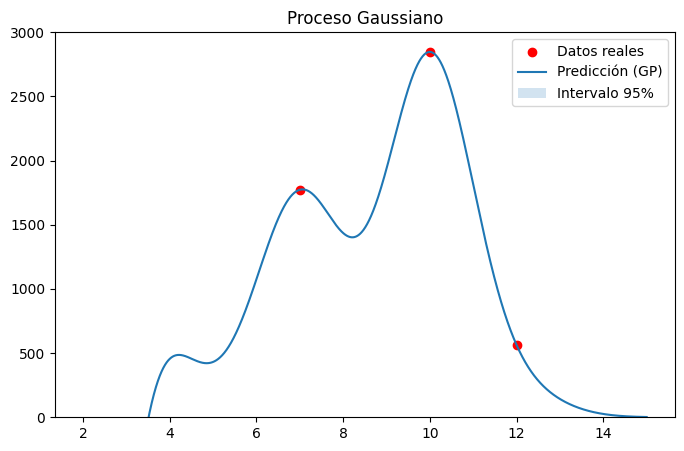

In [219]:
plt.figure(figsize=(8,5))

# puntos reales
plt.scatter(x, y, color='red', label='Datos reales')

# predicción
plt.plot(x_sim, ypred, label='Predicción (GP)')

# intervalo de confianza 95%
y_upper = ypred + 2*sigma
y_lower = ypred - 2*sigma

plt.fill_between(
    x_sim.ravel(),
    y_lower,
    y_upper,
    alpha=0.2,
    label='Intervalo 95%'
)

plt.ylim([0, 3000])
plt.legend()
plt.title("Proceso Gaussiano")
plt.show()

In [220]:
acq = ypred + 2*sigma
indice = np.argmax(acq)
x_next = x_sim[indice]
x_next

array([9.9963])

## Prueba 2
Se agregó el nuevo punto obtenido

|                |   |
:----------------|---|
| *x*     |*y*  |
| 10      |2847  |
| 2|-4017   |
| 3|-1255   |
| 7|1773  |
| 12|563   |
| 9.9963|2847.313   |

In [221]:
x = np.array([10, 2, 3, 7, 12, 9.9963]).reshape(-1, 1)
y = np.array([2847, -4017, -1255, 1773, 563, 2847.31363])

In [222]:
kernel = 1.0 * RBF(length_scale=1.0)

In [223]:
gp = GaussianProcessRegressor(n_restarts_optimizer=10)

In [224]:
gp.fit(x, y)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [225]:
x_sim = np.linspace(2, 15, 10001).reshape(-1,1)

In [226]:
ypred, sigma = gp.predict(x_sim, return_std=True)

In [227]:
acq = ypred + 2*sigma
indice = np.argmax(acq)
x_next = x_sim[indice]
x_next

array([9.9651])

## Prueba 3
Se agregó el nuevo punto obtenido
|                |   |
:----------------|---|
| *x*     |*y*  |
| 10      |2847  |
| 2|-4017   |
| 3|-1255   |
| 7|1773  |
| 12|563   |
| 9.9963|2847.313   |
| 9.9951|2849.5981   |

In [228]:
x = np.array([10, 2, 3, 7, 12, 9.9963, 9.9651]).reshape(-1, 1)
y = np.array([2847, -4017, -1255, 1773, 563, 2847.31363, 2849.5981])

In [229]:
gp = GaussianProcessRegressor(n_restarts_optimizer=10)

In [230]:
gp.fit(x, y)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [231]:
x_sim = np.linspace(2, 15, 10001).reshape(-1,1)

In [232]:
ypred, sigma = gp.predict(x_sim, return_std=True)

In [233]:
acq = ypred + 2*sigma
indice = np.argmax(acq)
x_next = x_sim[indice]
x_next

array([9.8741])

## Tabla después de prueba 3
|                |   |
:----------------|---|
| *x*     |*y*  |
| 10      |2847  |
| 2|-4017   |
| 3|-1255   |
| 7|1773  |
| 12|563   |
| 9.9963|2847.313   |
| 9.9951|2849.5981   |
| 9.8741|2852.6971   |

## Conclusión

La optimización gaussiana permite encontrar el valor óptimo de una función de manera eficiente utilizando pocos datos, ya que combina la predicción del modelo con su incertidumbre. A medida que se agregan nuevos puntos, el modelo mejora su ajuste y se acerca cada vez más al óptimo.